# Data Preprocessing and Modeling

## CRISP-DM Phase 7: Data Preprocessing and Modeling

### Project: Customer Churn Analysis

Data Preprocessing and Modeling is the process of preparing the feature-engineered dataset for machine learning and developing predictive models to identify customers who are likely to churn.

The objectives of this notebook are to:

- Load the feature-engineered customer churn dataset
- Separate input features and the target variable
- Identify numerical and categorical features
- Handle any remaining missing or invalid values
- Encode categorical variables
- Scale numerical features where required
- Split the dataset into training and testing sets
- Address class imbalance in the target variable
- Build baseline machine learning models
- Train multiple classification algorithms
- Evaluate model performance using appropriate metrics
- Compare the performance of different models
- Perform hyperparameter tuning where appropriate
- Select the best-performing model
- Analyze feature importance and model interpretability
- Validate the final model on unseen test data
- Save the trained model and preprocessing pipeline for future predictions

### Input

Feature-engineered customer churn dataset

### Output

A trained and evaluated machine learning model capable of predicting customer churn, along with the required preprocessing pipeline.

### Key Areas of Preprocessing

- **Feature and Target Separation:** Separate independent variables from the churn target
- **Train-Test Split:** Divide the dataset into training and testing subsets
- **Categorical Encoding:** Convert categorical variables into numerical representations
- **Feature Scaling:** Standardize numerical features where required
- **Missing Value Handling:** Address any remaining missing values
- **Class Imbalance:** Analyze and handle imbalance between churned and retained customers
- **Data Leakage Prevention:** Ensure preprocessing is learned only from the training data
- **Pipeline Creation:** Combine preprocessing steps into a reproducible machine learning pipeline

### Key Areas of Modeling

- **Baseline Model:** Establish an initial benchmark for model performance
- **Logistic Regression:** Build an interpretable baseline classification model
- **Decision Tree:** Analyze nonlinear relationships and decision rules
- **Random Forest:** Build an ensemble model using multiple decision trees
- **Gradient Boosting:** Evaluate a boosting-based classification approach
- **Other Classification Models:** Test additional suitable algorithms where appropriate
- **Hyperparameter Tuning:** Optimize model parameters to improve performance
- **Cross-Validation:** Evaluate model stability across multiple data splits
- **Model Comparison:** Compare models using consistent evaluation metrics
- **Model Selection:** Select the model that provides the best balance of performance and interpretability

### Model Evaluation Metrics

The models will be evaluated using:

- **Accuracy:** Overall proportion of correctly classified customers
- **Precision:** Proportion of predicted churners who actually churned
- **Recall:** Proportion of actual churners correctly identified
- **F1-Score:** Balance between precision and recall
- **ROC-AUC:** Ability of the model to distinguish between churned and retained customers
- **Confusion Matrix:** Detailed view of correct and incorrect predictions

### Expected Outcomes

The preprocessing and modeling process should help to:

- Prepare a clean and model-ready dataset
- Establish reliable machine learning pipelines
- Identify the most effective classification algorithm
- Accurately predict customers at risk of churn
- Minimize false negatives for potential churners
- Understand the factors influencing model predictions
- Produce a reproducible and deployable machine learning model

### Conclusion

The final selected model will be used to predict customer churn and identify customers who are at higher risk of leaving. The model evaluation results and feature importance analysis will provide a foundation for developing targeted customer retention strategies and supporting business decision-making.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pandas as pd
import numpy as np

# Data Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
print("Loaded libraries successfully")

Loaded libraries successfully


In [ ]:
engine = create_engine(
    f"postgresql://{DB_CONFIG["user"]}:{DB_CONFIG["password"]}@{DB_CONFIG["host"]}:{DB_CONFIG["port"]}/{DB_CONFIG["database"]}"
)

query = "SELECT * FROM customer_churn_clean_eda_fe;"
customer_churn = pd.read_sql(query, engine)

df.head()

,Unnamed: 0.1,Unnamed: 0,customerid,count,country,state,city,zip_code,lat_long,latitude,...,churn_label,churn_value,churn_score,cltv,churn_reason,is_churned,cltv_band,tenure_band,protection_support_count,entertainment_count
0,0,0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,...,Yes,1,86,3239,Competitor made better offer,True,low,Very Short Tenure,2,0
1,1,1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,...,Yes,1,67,2701,Moved,True,low,Very Short Tenure,0,0
2,2,2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,...,Yes,1,86,5372,Moved,True,high,Very Short Tenure,1,2
3,3,3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,...,Yes,1,84,5003,Moved,True,high,Short Tenure,2,2
4,4,4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,...,Yes,1,89,5340,Competitor had better devices,True,high,Long Tenure,2,2


## 1. Selecting the Relevant Columns

In [4]:
df_preprocess = df[['city','gender',
                    'senior_citizen', 'partner',
                    'dependents', 'tenure_months',
                    'phone_service','internet_service', 'payment_method', 'monthly_charges', 'total_charges', 'churn_label', 'cltv', 'protection_support_count',
                    'entertainment_count']]
df_preprocess.head()

,city,gender,senior_citizen,partner,dependents,tenure_months,phone_service,internet_service,payment_method,monthly_charges,total_charges,churn_label,cltv,protection_support_count,entertainment_count
0,Los Angeles,Male,No,No,No,2,Yes,DSL,Mailed check,53.85,108.15,Yes,3239,2,0
1,Los Angeles,Female,No,No,Yes,2,Yes,Fiber optic,Electronic check,70.70,151.65,Yes,2701,0,0
2,Los Angeles,Female,No,No,Yes,8,Yes,Fiber optic,Electronic check,99.65,820.50,Yes,5372,1,2
3,Los Angeles,Female,No,Yes,Yes,28,Yes,Fiber optic,Electronic check,104.80,3046.05,Yes,5003,2,2
4,Los Angeles,Male,No,No,Yes,49,Yes,Fiber optic,Bank transfer (automatic),103.70,5036.30,Yes,5340,2,2


In [5]:
# Features
X = df_preprocess[['city','gender',
                    'senior_citizen', 'partner',
                    'dependents', 'tenure_months',
                    'phone_service','internet_service', 'payment_method', 'monthly_charges', 'total_charges', 'cltv', 'protection_support_count',
                    'entertainment_count']]

# Target
Y = df_preprocess['churn_label']

In [6]:
city_counts = df_preprocess['city'].value_counts()

city_counts.describe()

count    1129.000000
mean        6.238264
std        12.254863
min         4.000000
25%         4.000000
50%         4.000000
75%         5.000000
max       305.000000
Name: count, dtype: float64

In [7]:
(city_counts < 100).sum()

np.int64(1124)

### Handling the `city` Feature

The `city` feature was initially considered for the churn prediction model because EDA showed differences in churn rates across cities. However, the dataset contains **1,129 unique cities**, with **1,124 cities having fewer than 100 customers**.

One-hot encoding all cities would result in a large number of sparse features, while grouping cities using a threshold of 100 customers would retain only a very small number of cities and potentially discard useful geographic information.

Therefore, `city` will be **excluded from the initial model**. This decision can be revisited later if model evaluation or additional geographic feature engineering suggests that location provides meaningful predictive value.


In [8]:
X = X.drop(['city'], axis = 1)
X.head()

,gender,senior_citizen,partner,dependents,tenure_months,phone_service,internet_service,payment_method,monthly_charges,total_charges,cltv,protection_support_count,entertainment_count
0,Male,No,No,No,2,Yes,DSL,Mailed check,53.85,108.15,3239,2,0
1,Female,No,No,Yes,2,Yes,Fiber optic,Electronic check,70.70,151.65,2701,0,0
2,Female,No,No,Yes,8,Yes,Fiber optic,Electronic check,99.65,820.50,5372,1,2
3,Female,No,Yes,Yes,28,Yes,Fiber optic,Electronic check,104.80,3046.05,5003,2,2
4,Male,No,No,Yes,49,Yes,Fiber optic,Bank transfer (automatic),103.70,5036.30,5340,2,2


## 2. Encoding Columns

In [9]:
binary_features = [
    'gender',
    'senior_citizen',
    'partner',
    'dependents',
    'phone_service'
]

nominal_features = [
    'internet_service',
    'payment_method'
]

numerical_features = [
    'tenure_months',
    'monthly_charges',
    'total_charges',
    'cltv',
    'protection_support_count',
    'entertainment_count'
]

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'binary',
            OrdinalEncoder(
                categories=[
                    ['Female', 'Male'],
                    ['No', 'Yes'],
                    ['No', 'Yes'],
                    ['No', 'Yes'],
                    ['No', 'Yes']
                ]
            ),
            binary_features
        ),
        (
            'nominal',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),
            nominal_features
        ),
        (
            'numerical',
            StandardScaler(),
            numerical_features
        )
    ]
)

In [11]:
# Encode the target variable
Y = Y.map({
    'No': 0,
    'Yes': 1
})


## 3. Train-Test Split

Before applying preprocessing transformations, the dataset is divided into training and testing sets. The preprocessing steps will be fitted only on the training data to prevent data leakage.

The target variable, `churn_label`, is encoded as:

* `No` → `0`
* `Yes` → `1`

Stratified sampling is used to ensure that the proportion of churned and non-churned customers remains consistent across both the training and testing datasets.


In [12]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42,
    stratify=Y
)

In [13]:
# Fitting and transforming the data
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [14]:
# Checking the results
print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("Original testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Original training shape: (5634, 13)
Processed training shape: (5634, 18)
Original testing shape: (1409, 13)
Processed testing shape: (1409, 18)


In [15]:
print(X_train_processed[:5])

[[ 0.          0.          1.          0.          1.          0.
   1.          0.          0.          0.          1.          0.
  -1.24032938  0.63749449 -0.94983561 -1.92325527 -0.98973078  0.25695435]
 [ 1.          0.          1.          1.          1.          0.
   1.          0.          0.          0.          0.          1.
  -0.70972214  0.33938811 -0.50039453  0.20795046 -0.21213446 -0.91430844]
 [ 1.          0.          1.          1.          0.          1.
   0.          0.          0.          0.          0.          1.
  -0.79135402 -0.81140244 -0.74828282 -1.26079632  1.34305818 -0.91430844]
 [ 1.          0.          1.          1.          1.          0.
   0.          1.          0.          0.          0.          1.
   1.53515465 -1.31601827 -0.22189566  0.4786872  -0.98973078 -0.91430844]
 [ 1.          0.          0.          0.          1.          0.
   1.          0.          0.          0.          1.          0.
  -0.91380185  0.49760099 -0.65689279  1

In [16]:
feature_names = preprocessor.get_feature_names_out()

print(feature_names)

['binary__gender' 'binary__senior_citizen' 'binary__partner'
 'binary__dependents' 'binary__phone_service'
 'nominal__internet_service_DSL' 'nominal__internet_service_Fiber optic'
 'nominal__internet_service_No'
 'nominal__payment_method_Bank transfer (automatic)'
 'nominal__payment_method_Credit card (automatic)'
 'nominal__payment_method_Electronic check'
 'nominal__payment_method_Mailed check' 'numerical__tenure_months'
 'numerical__monthly_charges' 'numerical__total_charges' 'numerical__cltv'
 'numerical__protection_support_count' 'numerical__entertainment_count']


## 4. Base Modeling

In [17]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    
    'Decision Tree': DecisionTreeClassifier(
        random_state=42
    ),
    
    'Random Forest': RandomForestClassifier(
        random_state=42
    ),
    
    'Gradient Boosting': GradientBoostingClassifier(
        random_state=42
    )
}

In [18]:
def train_models(models, X_train, y_train):
    
    trained_models = {}
    
    for name, model in models.items():
        model.fit(X_train, y_train)
        trained_models[name] = model
    
    return trained_models

In [19]:
trained_models = train_models(
    models,
    X_train_processed,
    y_train
)

In [20]:
def evaluate_models(models, X_test, y_test):
    
    results = []

    for name, model in models.items():
        
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
        
        results.append({
            'Model': name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred),
            'F1 Score': f1_score(y_test, y_pred),
            'ROC-AUC': roc_auc_score(y_test, y_prob)
        })

    return pd.DataFrame(results)

In [21]:
model_results = evaluate_models(
    trained_models,
    X_test_processed,
    y_test
)

model_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.818311,0.694079,0.564171,0.622419,0.856537
1,Decision Tree,0.733144,0.497436,0.518717,0.507853,0.664672
2,Random Forest,0.803407,0.660066,0.534759,0.590842,0.839669
3,Gradient Boosting,0.806955,0.663462,0.553476,0.603499,0.858223


### Baseline Model Selection

Four classification models were evaluated: Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting.

Based on the initial test-set evaluation, Decision Tree was removed from further consideration because it consistently underperformed the other models across the key evaluation metrics.

Logistic Regression, Random Forest, and Gradient Boosting were retained for further evaluation because they demonstrated stronger overall predictive performance, particularly in terms of F1-score and ROC-AUC.

## 5. Cross Validation

In [22]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [23]:
def cross_validate_models(models, X, y, cv):
    
    results = []

    scoring = {
        'accuracy': 'accuracy',
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1',
        'roc_auc': 'roc_auc'
    }

    for name, model in models.items():
        
        scores = cross_validate(
            model,
            X,
            y,
            cv=cv,
            scoring=scoring
        )

        results.append({
            'Model': name,
            'Accuracy': scores['test_accuracy'].mean(),
            'Precision': scores['test_precision'].mean(),
            'Recall': scores['test_recall'].mean(),
            'F1 Score': scores['test_f1'].mean(),
            'ROC-AUC': scores['test_roc_auc'].mean()
        })

    return pd.DataFrame(results)

In [24]:
models_for_cv = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    
    'Random Forest': RandomForestClassifier(
        random_state=42
    ),
    
    'Gradient Boosting': GradientBoostingClassifier(
        random_state=42
    )
}

In [25]:
cv_results = cross_validate_models(
    models_for_cv,
    X_train_processed,
    y_train,
    cv
)

cv_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.803869,0.660978,0.534448,0.590625,0.847550
1,Random Forest,0.788958,0.629046,0.498328,0.555899,0.830192
2,Gradient Boosting,0.799786,0.652742,0.524415,0.581438,0.850043


### Cross-Validation Model Selection

Five-fold stratified cross-validation was performed to assess whether the baseline model performance was consistent across different subsets of the training data.

Logistic Regression achieved the strongest overall cross-validation performance, while Gradient Boosting achieved the highest ROC-AUC by a small margin. Random Forest performed slightly lower than the other two models.

Since the differences between the models were relatively small, Logistic Regression, Random Forest, and Gradient Boosting were retained for hyperparameter tuning rather than selecting a final model based only on baseline performance.

## 6. Hyperparameter tunning

In [26]:
lr_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'class_weight': [None, 'balanced'],
    'solver': ['liblinear', 'lbfgs']
}

In [27]:
rf_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [None, 'balanced']
}

In [28]:
gb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 1.0]
}

In [29]:
tuning_models = {
    'Logistic Regression': (
        LogisticRegression(max_iter=1000, random_state=42),
        lr_params
    ),
    
    'Random Forest': (
        RandomForestClassifier(random_state=42),
        rf_params
    ),
    
    'Gradient Boosting': (
        GradientBoostingClassifier(random_state=42),
        gb_params
    )
}

In [30]:
def tune_models(models, X_train, y_train, cv, scoring='f1', n_iter=20):
    
    tuned_models = {}
    
    for name, (model, params) in models.items():
        
        search = RandomizedSearchCV(
            estimator=model,
            param_distributions=params,
            n_iter=n_iter,
            scoring=scoring,
            cv=cv,
            random_state=42,
            n_jobs=-1
        )
        
        search.fit(X_train, y_train)
        
        tuned_models[name] = search
        
    return tuned_models

In [31]:
tuned_models = tune_models(
    tuning_models,
    X_train_processed,
    y_train,
    cv
)

In [32]:
for name, search in tuned_models.items():
    print(f'\n{name}')
    print('Best F1 Score:', search.best_score_)
    print('Best Parameters:', search.best_params_)


Logistic Regression
Best F1 Score: 0.6326120533575866
Best Parameters: {'solver': 'lbfgs', 'class_weight': 'balanced', 'C': 0.1}

Random Forest
Best F1 Score: 0.6364939383382227
Best Parameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 5, 'class_weight': 'balanced'}

Gradient Boosting
Best F1 Score: 0.5881626197093135
Best Parameters: {'subsample': 1.0, 'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 2, 'learning_rate': 0.1}


### Hyperparameter Tuning

RandomizedSearchCV was used to optimize the retained models using F1-score as the primary scoring metric.

F1-score was selected because the objective is to identify customers likely to churn while maintaining a reasonable balance between precision and recall.

After tuning, Random Forest achieved the highest cross-validated F1-score of **0.6365**, followed by Logistic Regression with **0.6326**. Gradient Boosting performed considerably lower with an F1-score of **0.5882**.

Therefore, Gradient Boosting was removed from further consideration, while the tuned Logistic Regression and Random Forest models were evaluated on the untouched test set.

In [33]:
final_models = {
    'Logistic Regression': tuned_models['Logistic Regression'].best_estimator_,
    'Random Forest': tuned_models['Random Forest'].best_estimator_
}

In [34]:
final_results = evaluate_models(
    final_models,
    X_test_processed,
    y_test
)

final_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.761533,0.535185,0.772727,0.632385,0.856292
1,Random Forest,0.767921,0.542342,0.804813,0.648009,0.858876


### Final Model Selection

The tuned Logistic Regression and Random Forest models were evaluated on the previously untouched test set.

Random Forest achieved better performance than Logistic Regression across all evaluation metrics:

- **Accuracy:** 76.79%
- **Precision:** 54.23%
- **Recall:** 80.48%
- **F1-score:** 64.80%
- **ROC-AUC:** 85.89%

Random Forest was therefore selected as the final model.

The most important factor in this decision was its **higher recall and F1-score for churn prediction**. The model correctly identifies approximately 80% of customers who actually churn, which is particularly valuable for a customer retention use case.

Although the precision is relatively moderate, the higher recall means fewer actual churners are missed. This trade-off is considered appropriate because failing to identify a customer who is likely to churn can result in a missed retention opportunity.

In [35]:
def plot_confusion_matrix(model, X_test, y_test):
    
    y_pred = model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    
    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No Churn', 'Churn']
    )
    
    display.plot()
    plt.title('Random Forest - Confusion Matrix')
    plt.show()

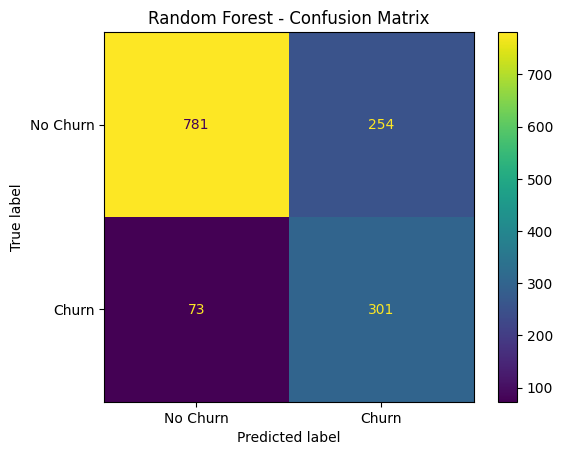

In [36]:
plot_confusion_matrix(
    final_models['Random Forest'],
    X_test_processed,
    y_test
)

In [37]:
def get_classification_report(model, X_test, y_test):
    
    y_pred = model.predict(X_test)
    
    report = classification_report(
        y_test,
        y_pred,
        target_names=['No Churn', 'Churn']
    )
    
    print(report)

In [38]:
get_classification_report(
    final_models['Random Forest'],
    X_test_processed,
    y_test
)

              precision    recall  f1-score   support

    No Churn       0.91      0.75      0.83      1035
       Churn       0.54      0.80      0.65       374

    accuracy                           0.77      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.82      0.77      0.78      1409



### Classification Report Analysis

The final Random Forest model achieved a recall of **80% for the Churn class**, indicating that the model successfully identifies the majority of customers who actually churn.

The churn precision of **54%** indicates that the model also identifies some customers who ultimately do not churn. This is a reasonable trade-off given the objective of maximizing the detection of potential churners.

The resulting churn F1-score of **0.65** demonstrates a reasonable balance between identifying churners and limiting incorrect churn predictions.

Overall, the classification report supports the selection of Random Forest as the final model for this churn prediction problem.

In [39]:
def get_feature_importance(model, feature_names, top_n=15):
    
    importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': model.feature_importances_
    })
    
    importance = importance.sort_values(
        by='Importance',
        ascending=False
    ).head(top_n)
    
    return importance

In [40]:
feature_names = preprocessor.get_feature_names_out()

In [41]:
feature_importance = get_feature_importance(
    final_models['Random Forest'],
    feature_names
)

feature_importance

,Feature,Importance
12,numerical__tenure_months,0.219211
6,nominal__internet_service_Fiber optic,0.150364
14,numerical__total_charges,0.127632
3,binary__dependents,0.106710
10,nominal__payment_method_Electronic check,0.096657
13,numerical__monthly_charges,0.083732
7,nominal__internet_service_No,0.067482
16,numerical__protection_support_count,0.056568
5,nominal__internet_service_DSL,0.033894
15,numerical__cltv,0.015831


In [42]:
def plot_feature_importance(feature_importance):
    
    plt.figure(figsize=(10, 6))
    
    plt.barh(
        feature_importance['Feature'][::-1],
        feature_importance['Importance'][::-1]
    )
    
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.title('Random Forest - Feature Importance')
    plt.show()

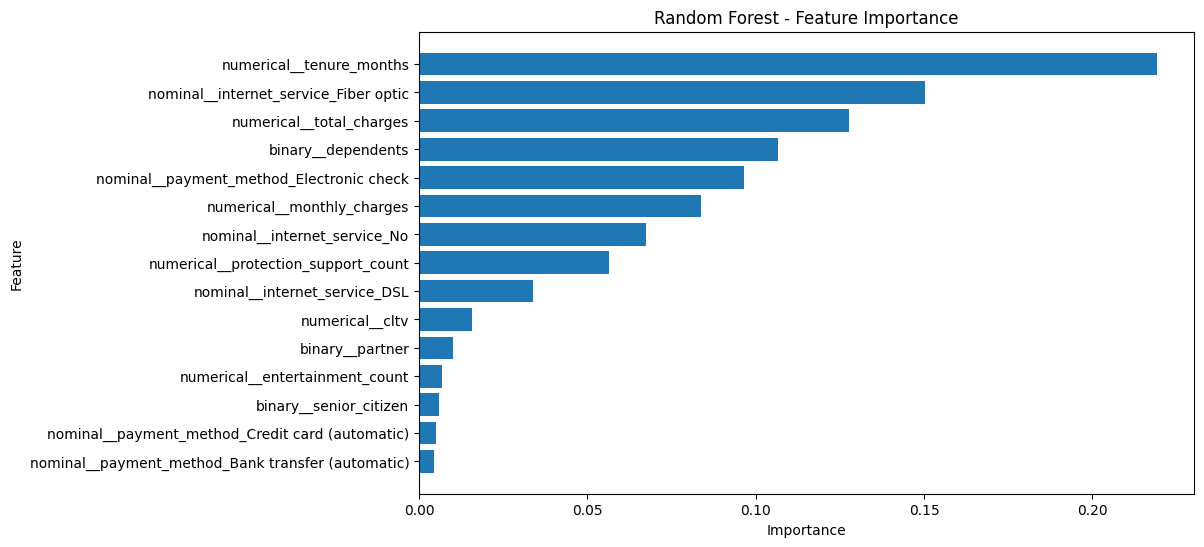

In [43]:
plot_feature_importance(feature_importance)

### Final Model Selection Summary

After comparing multiple classification algorithms, performing cross-validation, tuning hyperparameters, and evaluating the final candidates on the untouched test set, **Random Forest was selected as the final churn prediction model**.

The final model achieved:

| Metric | Score |
|---|---:|
| Accuracy | 76.79% |
| Precision | 54.23% |
| Recall | 80.48% |
| F1-score | 64.80% |
| ROC-AUC | 85.89% |

Random Forest was selected primarily because it provided the best overall performance on the final test set and achieved the highest recall and F1-score among the final candidate models.

Its **80.48% recall for churn** makes it particularly suitable for the business objective of identifying customers at risk of leaving, where missing an actual churner may represent a lost retention opportunity.

The model will therefore be used as the final model for the subsequent deployment stage.

## 7. Final Pipeline

In [44]:
# Creating the final pipeline
final_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        
        (
            'model',
            RandomForestClassifier(
                n_estimators=200,
                min_samples_split=10,
                min_samples_leaf=2,
                max_features='sqrt',
                max_depth=5,
                class_weight='balanced',
                random_state=42
            )
        )
    ]
)

In [45]:
final_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('binary',
                                                  OrdinalEncoder(categories=[['Female',
                                                                              'Male'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes']]),
                                                  ['gender', 'senior_citizen',
                                                   'partner', 'dependents',
                                                   'phone_service']),
                                                 ('nominal',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['internet_service',
                                                   'payment_method']),
                                                 ('numerical', StandardScaler(),
                                                  ['tenure_months',
                                                   'monthly_charges',
                                                   'total_charges', 'cltv',
                                                   'protection_support_count',
                                                   'entertainment_count'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=5,
                                        min_samples_leaf=2,
                                        min_samples_split=10, n_estimators=200,
                                        random_state=42))])

In [46]:
y_pred = final_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7679205110007097
Precision: 0.5423423423423424
Recall: 0.8048128342245989
F1 Score: 0.6480086114101185

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.75      0.83      1035
           1       0.54      0.80      0.65       374

    accuracy                           0.77      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.82      0.77      0.78      1409


Confusion Matrix:
[[781 254]
 [ 73 301]]


In [ ]:
# Saving the pipeline
joblib.dump(
    final_pipeline,
    'customer-churn-prediction/models/customer_churn_pipeline.joblib'
)

['/kaggle/working/customer_churn_pipeline.joblib']

# Final Model Evaluation and Selection

## 1. Model Selection Approach

Multiple classification algorithms were evaluated to identify the most suitable model for predicting customer churn.

The following models were initially considered:

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting

The models were evaluated using **Accuracy, Precision, Recall, F1-score, and ROC-AUC**.

Since the primary objective of this project is to identify customers who are likely to churn, particular importance was given to **Recall and F1-score for the Churn class**.

---

## 2. Baseline Model Evaluation

The initial evaluation showed that Decision Tree consistently underperformed compared with the other models and was therefore removed from further consideration.

Logistic Regression, Random Forest, and Gradient Boosting demonstrated stronger overall performance and were retained for cross-validation and hyperparameter tuning.

---

## 3. Cross-Validation

Five-fold stratified cross-validation was performed on the retained models to evaluate the consistency of their performance across different subsets of the training data.

The results showed that:

- **Logistic Regression** achieved the strongest overall cross-validation performance.
- **Gradient Boosting** achieved the highest ROC-AUC by a small margin.
- **Random Forest** performed slightly below Logistic Regression and Gradient Boosting.

Because the differences were relatively small, Logistic Regression, Random Forest, and Gradient Boosting were retained for hyperparameter tuning rather than selecting a final model based solely on baseline performance.

---

## 4. Hyperparameter Tuning

`RandomizedSearchCV` was used to tune the retained models.

**F1-score** was selected as the primary optimization metric because it provides a balance between Precision and Recall and is particularly useful for the churn prediction problem.

The best cross-validated F1-scores were:

| Model | Best F1-score |
|---|---:|
| Logistic Regression | 0.6326 |
| Random Forest | **0.6365** |
| Gradient Boosting | 0.5882 |

Random Forest achieved the highest F1-score after tuning, while Gradient Boosting showed a significant decline in performance.

Therefore, **Logistic Regression and Random Forest** were selected for final evaluation on the untouched test set.

---

## 5. Final Test Set Evaluation

The tuned Logistic Regression and Random Forest models were evaluated using the previously untouched test set.

| Model | Accuracy | Precision | Recall | F1-score | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Logistic Regression | 76.15% | 53.52% | 77.27% | 63.24% | 85.63% |
| **Random Forest** | **76.79%** | **54.23%** | **80.48%** | **64.80%** | **85.89%** |

Random Forest achieved better performance than Logistic Regression across **all five evaluation metrics**.

The most significant advantage was its higher Recall and F1-score for churn prediction.

---

## 6. Classification Report

The final Random Forest model produced the following results:

| Class | Precision | Recall | F1-score | Support |
|---|---:|---:|---:|---:|
| No Churn | 0.91 | 0.75 | 0.83 | 1035 |
| Churn | 0.54 | **0.80** | **0.65** | 374 |
| **Accuracy** | | | **0.77** | **1409** |

The model achieves approximately **80% recall for the Churn class**, meaning it correctly identifies the majority of customers who actually churn.

The churn precision of approximately **54%** indicates that some customers predicted as churners will not actually churn. This represents a reasonable trade-off because the project prioritizes identifying potential churners and reducing the number of actual churners missed by the model.

---

## 7. Feature Importance

Feature importance was examined to understand which variables contribute most to the Random Forest's predictions.

The most influential features were:

| Rank | Feature | Importance |
|---:|---|---:|
| 1 | Tenure Months | 21.92% |
| 2 | Internet Service – Fiber Optic | 15.04% |
| 3 | Total Charges | 12.76% |
| 4 | Dependents | 10.67% |
| 5 | Payment Method – Electronic Check | 9.67% |
| 6 | Monthly Charges | 8.37% |
| 7 | Internet Service – No | 6.75% |
| 8 | Protection/Support Count | 5.66% |
| 9 | Internet Service – DSL | 3.39% |
| 10 | CLTV | 1.58% |

**Tenure** was the most influential feature, accounting for approximately **21.9%** of the model's impurity-based feature importance.

The importance of tenure, internet service, and customer charges is broadly consistent with the patterns identified during the exploratory data analysis and feature engineering stages.

Feature importance indicates how useful a feature is to the model's predictions and should not be interpreted as evidence of causation.

---

# 8. Final Model Selection

Based on the complete modelling process, **Random Forest was selected as the final model**.

The selection was based on the following factors:

- It achieved the highest F1-score during hyperparameter tuning.
- It achieved the best performance among the final candidates on the untouched test set.
- It achieved the highest Recall for the Churn class.
- It achieved the highest F1-score on the Churn class.
- It achieved the highest ROC-AUC among the final candidates.
- Its performance remained reasonably consistent between cross-validation and final test evaluation.

The final Random Forest model achieved:

- **Accuracy:** 76.79%
- **Precision:** 54.23%
- **Recall:** 80.48%
- **F1-score:** 64.80%
- **ROC-AUC:** 85.89%

The model's **80.48% churn recall** is particularly valuable for the business objective because it allows the company to identify a large proportion of customers who are at risk of leaving.

Although the model has moderate precision, this trade-off is acceptable for a retention-focused use case where missing an actual churner may represent a greater business cost than contacting some customers who ultimately remain.

---

## 9. Final Model Configuration

The selected Random Forest model uses the following hyperparameters:

```python
{
    'n_estimators': 200,
    'max_depth': 5,
    'min_samples_split': 10,
    'min_samples_leaf': 2,
    'max_features': 'sqrt',
    'class_weight': 'balanced',
    'random_state': 42
}